# ME-433 Rocket Science
## HW 4
### Fanno flow & Supersonic Lift/Drag

#### Question 1 
Assume that coming into a pipe there exists a Mach 0.5 flow at 101325 Pa of pressure and 300 K temperature, gamma 1.4. If it first passes through a frictionless pipe with heat addition, and then passes through an adiabatic pipe with friction in such a fashion that it always results in an exit flow at M = 1. Determine all combinations of heat addition q, and pipe length L, for a friction factor of 0.004 and pipe diameter of 0.1 m which can
achieve this result. Plot your result as a graph of L as a function of q.

Assuming 
1. Steady state $\frac{\partial}{\partial t} = 0 $
2. inviscid flow with no internal viscocity 
3. Calorically perfect gas (CPG)
4. Cp approximation at 300K at 1.005 KJ/Kg * K



### FOR RAYLEIGH FLOW : 
<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW4/Rayleigh%20star%20relationships.png?raw=true" width="50%">

<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW4/Rayleigh%20starred%20quantities%20definition.png?raw=true" width="50%">


### FOR FANNO FLOW : 
<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW4/Fanno%20Flow%20relationship.png?raw=true" width="50%">




### strategy 

1. Wtih Rayleigh flow, I can calculate the energy input q as the function of outgoing mach M2 
2. With Fanno flow, I can calculate the required length to push to mach  L* as a function of M2 
3. Thus, this question is implicit parametric sweep of M2 from [0.5,1], data collection of the  q2 an L*, and plotting

In [100]:
import numpy as np
import matplotlib.pyplot as plt 

# CONSTANTS 
M_i = 0.5 #Mach number
P_i = 101325 #Pa 
T_i = 300 #K 
gamma = 1.4 #heat capacity ratio 
M2 = np.linspace(0.5, 1, 1000)
D = 0.1 
f = 0.004

#Lists to solve problem 
Lstar_q1 = []
Lstar_q2 = []


#Stagnation Temperature relationship, only works for isentropic process
def stagTemp(m, gamma, T): 
    M = m ** 2
    T_stag = (1 + ((gamma - 1)/2 ) * M) * T
    return T_stag
print(stagTemp(M_i, gamma, T_i))

315.0


In [101]:
#Lstar as dictionary of [m2, q, Lstar] value
# where m2 is a sweep of possible in-between mach values 
# q2 is required heat input to go from init to m2 mach 
# Lstar is required length to go from m2 to mach 1 


#RayleighFlow_q1 takes in the mach number, gamma, Inlet Temperature and return q 

def T_Ostar_ratio(m, gamma): 
    M = m ** 2
    return ((gamma + 1)*M)/((1+gamma*M)**2) * (2 + (gamma - 1)* M)

def RayleighFlow_q1(m_i, m_2, gamma, T_i):
    
    T_O1star_ratio = T_Ostar_ratio(m_i, gamma)
    T_O2star_ratio = T_Ostar_ratio(m_2, gamma)
   
    T_O1 = stagTemp(m_i, gamma, T_i)
    T_Ostar = T_O1/T_O1star_ratio
    T_O2 = T_O2star_ratio * T_Ostar

    q = 1.005 * (T_O2 - T_O1)

    return q

#FannoFlow q1 takes in the mach number, gamma, pipe Diameter, 
# and friction to output Lstar
def FannoFlow_q1(m, gamma, D, f): 
    M = m ** 2 
    fanno = ((1-M)/(gamma * M)) + (((gamma + 1)/(2 * gamma))) * np.log(((gamma + 1)*M)/(2 + (gamma -1)*M))
    Lstar = (fanno * D)/(4 * f)
    return(fanno, Lstar)

for m in M2: 
    _, Lstar = FannoFlow_q1(m, gamma, D, f)
    q = RayleighFlow_q1(M_i, m, gamma,T_i)

    Lstar_q1.append([m, q, Lstar])

print(Lstar_q1[:5])

[[np.float64(0.5), np.float64(0.0), np.float64(6.681626954489099)], [np.float64(0.5005005005005005), np.float64(0.3351301266862836), np.float64(6.6561392263064025)], [np.float64(0.501001001001001), np.float64(0.6698495317608697), np.float64(6.630747250288577)], [np.float64(0.5015015015015015), np.float64(1.0041577613495465), np.float64(6.605450621320549)], [np.float64(0.502002002002002), np.float64(1.338054365035181), np.float64(6.5802489363491175)]]


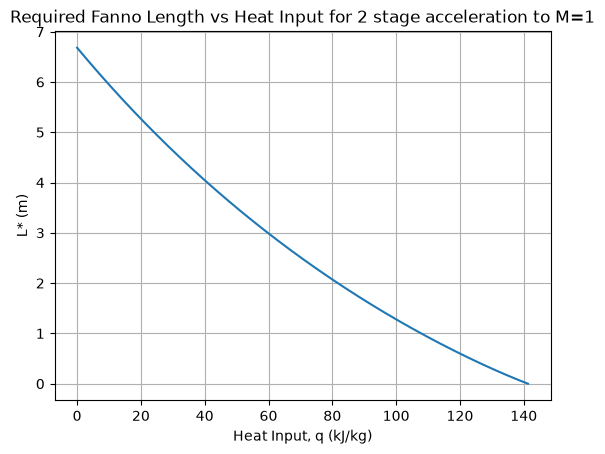

In [105]:
q_values = [row[1] for row in Lstar_q1]
Lstar_values = [row[2] for row in Lstar_q1]

plt.plot(q_values, Lstar_values)

plt.xlabel("Heat Input, q (kJ/kg)")
plt.ylabel("L* (m)")
plt.title("Required Fanno Length vs Heat Input for 2 stage acceleration to M=1")
plt.grid(True)
plt.show()


#### Question 2
Reverse the order of the processes in problem 1, comment on the differences in the two plots

In [107]:
#similar approach to Q1 

#Fanno_q2 need to take the M2, M_i, gamma,  friction, diameter 
#And return the length required to accelerate M_i to M_2 
#And return the temperature of M2 
def FannoFlow_q2(m_i, m_2, gamma, D, f, T): 
    M_i = m_i **2 
    M_2 = m_2 **2
    Fanno_M1 = -1/(gamma * M_i) - ((gamma+1)/(2*gamma)) * np.log(M_i)/(1 + ((gamma-1)/2)*M_i)
    Fanno_M2 = -1/(gamma * M_2) - ((gamma+1)/(2*gamma)) * np.log(M_2)/(1 + ((gamma-1)/2)*M_2)
    L = ((Fanno_M2-Fanno_M1) * D)/(4 * f)
    T_m2 = T * ((2 + (gamma-1)*M_i)/(2 + (gamma -1)*M_2))
    return T_m2, L

#Rayleigh_q2 need to take in M2 and find the required heat input q to reach the choke state 
# I can just reuse Rayleigh_q1 function and set the m_2, the end state Mach number, to 1


In [111]:
for m in M2: 
    T_m2, Lstar = FannoFlow_q2(M_i, m, gamma, D, f, T_i)
    q = RayleighFlow_q1(m, 1, gamma,T_m2)

    Lstar_q2.append([m, q, Lstar])

print(Lstar_q1[:5])

[[np.float64(0.5), np.float64(0.0), np.float64(6.681626954489099)], [np.float64(0.5005005005005005), np.float64(0.3351301266862836), np.float64(6.6561392263064025)], [np.float64(0.501001001001001), np.float64(0.6698495317608697), np.float64(6.630747250288577)], [np.float64(0.5015015015015015), np.float64(1.0041577613495465), np.float64(6.605450621320549)], [np.float64(0.502002002002002), np.float64(1.338054365035181), np.float64(6.5802489363491175)]]


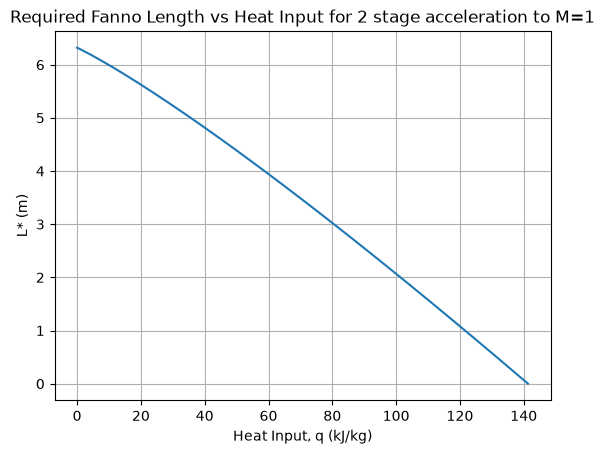

In [112]:
q_values = [row[1] for row in Lstar_q2]
Lstar_values = [row[2] for row in Lstar_q2]

plt.plot(q_values, Lstar_values)

plt.xlabel("Heat Input, q (kJ/kg)")
plt.ylabel("L* (m)")
plt.title("Required Fanno Length vs Heat Input for 2 stage acceleration to M=1")
plt.grid(True)
plt.show()

 Both graphs are similar that if you incrase the length of the Fanno Flow, you need less heat input and vice versa.

 However, Q2 where the flow goes from Fanno flow to Rayleigh flow draws concave down shape as the Fanno Flow decrease the temperature in the subsonic regime. while it draws concave up shape in Q1. 



#### Question 3 
Attached to your HW are four airfoil designs all given as the top surface of a symmetric airfoil in .txt format where the top row is x position and the bottom is y position. Plot on the same graph the lift coefficient as a function of the drag coefficient for the range of angle of attack from - 5 to 5 degrees. Assume a Mach number of 3 and gamma 1.4. You can take $L = \frac{1}{2}\rho v^2 C_L A $  and $D = \frac{1}{2}\rho v^2 C_D A $



as the appropriate expressions for lift and drag. Note that these are oriented normal to the wind for lift and parallel to the wind for drag. The area in these expressions can be taken to be the planform area of the wing, so its tip to tail length multiplied by a 1 m width into the page. Note that the density and velocity in the expressions above are the free stream values. The choice of a pressure and temperature is not necessary but for ease of calculation you can assume 1 atm and 300 K.

In [ ]:
#Takes in m and gamma to return nu_m, deflection angle in radian
def PrandtlMeyer (m, gamma): 
    M = m **2 
    nu_m = np.sqrt(((gamma+1)/(gamma-1))) * np.atan(np.sqrt(((gamma-1)*(gamma+1))*(M-1))) - np.atan(np.sqrt(M-1))
    return nu_m

def ExpansionWave (m_i, gamma, theta, T_i, P_i): 
    nu_m_i = PrandtlMeyer(M_i,gamma)
    nu_m_2 = theta - nu_m_2 

_IncompleteInputError: incomplete input (3771177316.py, line 11)

In [ ]:
airfoils = {}

for i in range(1, 5):
    with open(f"airfoil{i}.txt", "r") as file:
        lines = file.readlines()
    x = [float(value) for value in lines[0].strip().split(",")]
    y = [float(value) for value in lines[1].strip().split(",")]
    airfoils[i] = [x, y]
print(airfoils)

for i in range(1,5): 
    

{1: [[0.0, 0.5, 1.0], [0.0, 0.05, 0.0]], 2: [[0.0, 0.5, 1.0], [0.0, 0.025, 0.0]], 3: [[1.16573417585641e-15, 0.0494320508564344, 0.0990431305864551, 0.148813526701107, 0.198723463408589, 0.248753109471978, 0.298882586088981, 0.349091974790587, 0.399361325355481, 0.449670663737074, 0.5, 0.550329336262926, 0.600638674644519, 0.650908025209413, 0.701117413911019, 0.751246890528022, 0.801276536591411, 0.851186473298893, 0.900956869413545, 0.950567949143566, 0.999999999999999], [0.0, 0.0094744963884339, 0.017961810551876, 0.0254585701370629, 0.0319617963781345, 0.0374689052802224, 0.0419777086461739, 0.0454864149460108, 0.0479936300287789, 0.0494983576764971, 0.0499999999999998, 0.0494983576764971, 0.0479936300287789, 0.0454864149460108, 0.0419777086461739, 0.0374689052802224, 0.0319617963781345, 0.0254585701370629, 0.017961810551876, 0.0094744963884339, 0.0]], 4: [[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0], [0.0, 0.00

In [123]:

#If degree is negative, absolute value it and add it to the previous angle 
airfoil_angles = {}
def angleProcess(airfoils): 
    for i in range(1, 5): 
        x, y = airfoils[i]
        theta = []
        for j in range(1, len(x)):
            deltax = x[j] - x[j-1]
            deltay = y[j] - y[j-1]
            angle = np.rad2deg(np.arctan2(deltay, deltax))
            if j == 1: 
                theta.append(angle)
            elif angle < 0:
                theta.append(-(abs(angle) + theta[-1]))
            else: 
                theta.append(angle)
        airfoil_angles[i] = [x, theta]
    return airfoil_angles


In [124]:
angleProcess(airfoils)

{1: [[0.0, 0.5, 1.0],
  [np.float64(5.710593137499643), np.float64(-11.421186274999286)]],
 2: [[0.0, 0.5, 1.0],
  [np.float64(2.862405226111748), np.float64(-5.724810452223496)]],
 3: [[1.16573417585641e-15,
   0.0494320508564344,
   0.0990431305864551,
   0.148813526701107,
   0.198723463408589,
   0.248753109471978,
   0.298882586088981,
   0.349091974790587,
   0.399361325355481,
   0.449670663737074,
   0.5,
   0.550329336262926,
   0.600638674644519,
   0.650908025209413,
   0.701117413911019,
   0.751246890528022,
   0.801276536591411,
   0.851186473298893,
   0.900956869413545,
   0.950567949143566,
   0.999999999999999],
  [np.float64(10.850126961249778),
   np.float64(9.708008333748744),
   np.float64(8.565889706249669),
   np.float64(7.423771078749455),
   np.float64(6.2816524512496255),
   np.float64(5.139533823749899),
   np.float64(3.997415196249502),
   np.float64(2.8552965687500866),
   np.float64(1.7131779412493318),
   np.float64(0.5710593137502359),
   np.float64(-1.

### Question 4
Which airfoil does best? Typically for efficient operations it is desirable to maximize L/D. What conclusions can you draw from this analysis about the “optimal” design by this metric? Why is that a practical problem